## Data load

In [30]:
import pandas as pd

train_df = pd.read_csv('../data/train_cleaned.csv')
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


### පියවර 01: Features සහ Labels වෙන් කරමු
මචන්, මුලින්ම අපි කරන්න ඕනේ අපේ දත්ත පද්ධතිය කොටස් දෙකකට බෙදන එක:

1.  Features (X): අපි අනාවැකිය කීමට භාවිතා කරන දත්ත (Pclass, Sex, Age, etc.).

2. Label (y): අපි අනාවැකිය කිව යුතු දේ (Survived).

In [31]:
# 'Survived' තීරුව ඉවත් කර අනෙක් සියල්ල Features (X) ලෙස ගනිමු
features = train_df.drop('Survived', axis=1)

# 'Survived' තීරුව පමණක් Label (y) ලෙස ගනිමු
labels = train_df['Survived']

### පියවර 02: දත්ත බෙදීම (Train/Validation/Test Split)
දැන් අපි මේ දත්ත ටික කොටස් 3කට බෙදන්න ඕනේ. මතකද අපි කලින් ඉගෙන ගත්තා:

- Training Set (60%): මොඩලයට ඉගෙන ගැනීමට.

- Validation Set (20%): මොඩලය ටියුන් (Tune) කරන්න සහ හොඳම එක තෝරන්න.

- Test Set (20%): අවසානයේ මොඩලය කොච්චර දක්ෂද කියලා බලන්න.

In [32]:
# Sklearn වල තියෙන train_test_split පාවිච්චි කරලා මේක ලේසියෙන්ම කරන්න පුළුවන්:

from sklearn.model_selection import train_test_split
# මුලින්ම 60% ක් training වලටත් ඉතිරි 40% පරීක්ෂණ වලටත් වෙන් කරමු

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.4, random_state=42)

# අර 40% න් භාගයක් (ඒ කියන්නේ මුළු දත්ත වලින් 20% ක්) Validation සඳහා වෙන් කරමු

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# දැන් අපේ දත්ත බෙදී ඇති ආකාරය බලමු
print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")


Train: 534 | Val: 178 | Test: 179


## 🛠️ Logistic Regression: පියවරෙන් පියවර
- Logistic Regression එකකදී වෙන්නේ දත්ත අතර තියෙන සම්බන්ධතාවය ගොඩනගලා, යම් සිදුවීමක් වීමේ සම්භාවිතාව (Probability) ගණනය කරන එකයි.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score


# 1. මොඩලය හදාගමු (Initialize)
# C කියන්නේ regularization parameter එක (මතකයි නේද අපි කලින් ඉගෙන ගත්ත overfitting පාලනය කරන හැටි)
lr = LogisticRegression(C=1.0, max_iter=1000)

# 2. ට්‍රේනින්ග් ඩේටා දීලා මොඩලය පුහුණු කරමු (Fit)
lr.fit(X_train,y_train)

# 3. වැලිඩේෂන් සෙට් එකට අනාවැකි කියමු (Predict)
y_pred = lr.predict(X_val)

In [34]:
accuracy = round(accuracy_score(y_val, y_pred), 3)
precision = round(precision_score(y_val, y_pred), 3)
recall = round(recall_score(y_val, y_pred), 3)

print(f'Logistic Regression Results -- Accuracy: {accuracy} / Precision: {precision} / Recall: {recall}')

Logistic Regression Results -- Accuracy: 0.764 / Precision: 0.689 / Recall: 0.646


### 🔍 මොකක්ද මේ ප්‍රතිඵලවලින් කියවෙන්නේ?
- Accuracy (0.764): සමස්තයක් විදිහට මොඩලය මගීන් 100 දෙනෙක්ගෙන් 76 දෙනෙක් ගැනම නිවැරදි අනාවැකි පවසනවා.

- Precision (0.689): මොඩලය "මොහු බේරෙනවා" (Survived) කියලා කියපු අයගෙන් ඇත්තටම බේරුණේ 69%ක් විතරයි. ඒ කියන්නේ මොඩලය බේරුණේ නැති අයව "බේරෙනවා" කියලා වැරදියට හඳුනාගැනීමේ සම්භාවිතාවක් (False Positives) තියෙනවා.

- Recall (0.646): මේක තමයි මෙතන තියෙන දුර්වලම තැන. ඇත්තටම බේරුණු මගීන්ගෙන් මොඩලයට අහුවෙලා තියෙන්නේ 65%ක් විතරයි. ඒ කියන්නේ 35%ක්ම බේරුණු අයව මොඩලය හඳුනාගෙන නැහැ (False Negatives).

#### 🛠️ අපිට මේක වැඩි දියුණු කරන්න පුළුවන් කොහොමද?


- Option 1: Hyperparameter Tuning: අපි පාවිච්චි කරපු Logistic Regression එකේ C අගය (Regularization parameter) වෙනස් කරලා බලන එක. C අගය අඩු වැඩි කරද්දී Underfitting හෝ Overfitting පාලනය වෙලා ප්‍රතිඵල වෙනස් වෙන්න පුළුවන්.

- Option 2: Try a different Model: Logistic Regression කියන්නේ සරල linear මොඩලයක්. හැබැයි Titanic වගේ දත්තවල තියෙන සංකීර්ණ රටාවන් අඳුරගන්න Random Forest වැනි "Non-linear" මොඩලයක් වඩාත් සාර්ථක වෙන්න පුළුවන්.

### 🌲 Random Forest Classifier: පියවරෙන් පියවර
අපි මෙතනදී Hyperparameters දෙකක් පාවිච්චි කරනවා:


- n_estimators: අපි පාවිච්චි කරන Decision Trees ගණන (අපි 100කින් පටන් ගමු).


- max_depth: ගසක ගැඹුර (මොඩලය ඕනෑවට වඩා සංකීර්ණ වෙලා Overfit වෙන එක පාලනය කරන්න මේක උදව් වෙනවා).

In [35]:
from sklearn.ensemble import RandomForestClassifier
# 1. මොඩලය හදාගමු
rf = RandomForestClassifier(n_estimators=100, max_depth=10,random_state=42)

# 2. ට්‍රේනින්ග් ඩේටා දීලා මොඩලය පුහුණු කරමු
rf.fit(X_train,y_train)

# 3. වැලිඩේෂන් සෙට් එකට අනාවැකි කියමු
y_pred_rf = rf.predict(X_val)

### 📊 ප්‍රතිඵල සංසන්දනය කරමු (Model Comparison)

In [36]:
# Metrics ගණනය කරමු
accuracy_rf = round(accuracy_score(y_val, y_pred_rf), 3)
precision_rf = round(precision_score(y_val, y_pred_rf), 3)
recall_rf = round(recall_score(y_val, y_pred_rf), 3)

print(f'Random Forest Results -- Accuracy: {accuracy_rf} / Precision: {precision_rf} / Recall: {recall_rf}')

Random Forest Results -- Accuracy: 0.809 / Precision: 0.804 / Recall: 0.631


ඔයාට පෙනෙයි Random Forest එකේ Accuracy සහ Recall අගයන් Logistic Regression එකට වඩා වැඩි වෙලා තියෙන බව. මේකෙන් කියවෙන්නේ මොඩලය Titanic දත්තවල තියෙන "Non-linear" රටාවන් (උදා: වයස සහ පන්තිය අතර තියෙන සම්බන්ධය) වඩා හොඳින් හඳුනාගෙන තියෙන බවයි.

### 📊 Logistic Regression vs. Random Forest
- Metric  |    Logistic Regression |   Random Forest |   වෙනස
- Accuracy  |   0.764     |           0.809       |     +4.5% වගේ වැඩි වීමක්!
- Precision  | 0.689       |          0.804        |    ලොකු දියුණුවක්! (මොඩලය දැන් වඩාත් විශ්වාසදායකයි)
- Recall    |  0.646        |         0.631         |   පොඩි අඩුවීමක් තියෙනවා.

### 🛠️ ඊළඟ පියවර: GridSearchCV (The Ultimate Hyperparameter Tuner)

දැන් අපි බලමු මේ Recall එකත් වැඩි කරගෙන, Accuracy එක තවත් ඉහළට ගෙනියන්න පුළුවන්ද කියලා. අපි කලින් අතින් දුන්න max_depth වගේ අගයන් වෙනුවට, විවිධ අගයන් රැසක් ටෙස්ට් කරලා ඒ අතරින් හොඳම එක තෝරගන්න GridSearchCV පාවිච්චි කරමු.

In [37]:
from sklearn.model_selection import GridSearchCV

# අපි ටෙස්ට් කරන්න කැමති අගයන් (Hyperparameters)
param_grid = {
    'n_estimators': [10,50,100],
    'max_depth': [2,10,20,None],
    'min_samples_split': [2,5,10]
}

# GridSearchCV එක හදාගමු (අපි 5-fold cross-validation පාවිච්චි කරනවා)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# හොඳම අගයන් හොයමු
grid_search.fit(X_train, y_train)

# හොඳම අගයන් මොනවාද කියලා බලමු
print(f"Best Parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}


🧮 36 ආවේ කොහොමද?
GridSearchCV එක කරන්නේ අපි ලබාදෙන හැම Hyperparameter එකකම තියෙන අගයන් එකිනෙක ගලපලා (Combinations) බලන එකයි.  අපි කලින් param_grid එකේ දුන්නේ මේ අගයන් ටිකනේ:

n_estimators: [10, 50, 100] $\rightarrow$ අගයන් 3 කි.

max_depth: [2, 10, 20, None] $\rightarrow$ අගයන් 4 කි.

min_samples_split: [2, 5, 10] $\rightarrow$ අගයන් 3 කි.
එතකොට මුළු එකතුව (Total Combinations) වෙන්නේ මේ අගයන් එකිනෙක ගුණ කළාම ලැබෙන අගයයි:$$\text{Total Combinations} = 3 \times 4 \times 3 = 36$$අපි cv=5 (5-fold Cross-Validation) භාවිතා කරපු නිසා, මේ හැම combination එකක්ම 5 වතාවක් බැගින් ටෙස්ට් කරනවා. එතකොට පරිගණකය විසින් මුළු වාර 180ක් ($36 \times 5$) මොඩලය පුහුණු කරලා පරීක්ෂා කරලා තියෙනවා. ඔයාගේ PyCharm terminal එකේ verbose=2 දුන්න නිසා ඒ "Fits" 180ම රන් වෙන හැටි පෙනෙන්න ඇති.

### 🛠️ අවසාන පියවර: Best Model එකෙන් ප්‍රතිඵල බලමු

In [38]:
# GridSearchCV මගින් සොයාගත් හොඳම මොඩලය තෝරාගනිමු
best_rf_model = grid_search.best_estimator_

# Validation set එකට අනාවැකි කියමු
y_pred_best = best_rf_model.predict(X_val)



In [39]:
accuracy_final = round(accuracy_score(y_val, y_pred_best), 3)
precision_final = round(precision_score(y_val, y_pred_best), 3)
recall_final = round(recall_score(y_val, y_pred_best), 3)

print(f'Tuned Random Forest -- Accuracy: {accuracy_final} / Precision: {precision_final} / Recall: {recall_final}')

Tuned Random Forest -- Accuracy: 0.815 / Precision: 0.808 / Recall: 0.646


Metric | Logistic Regression |Basic Random Forest | Tuned Random Forest

Accuracy | 0.764 | 0.809 | 0.815 (Winner! 🏆)

Precision | 0.689 | 0.804 | 0.808

Recall | 0.646 | 0.631 | 0.646


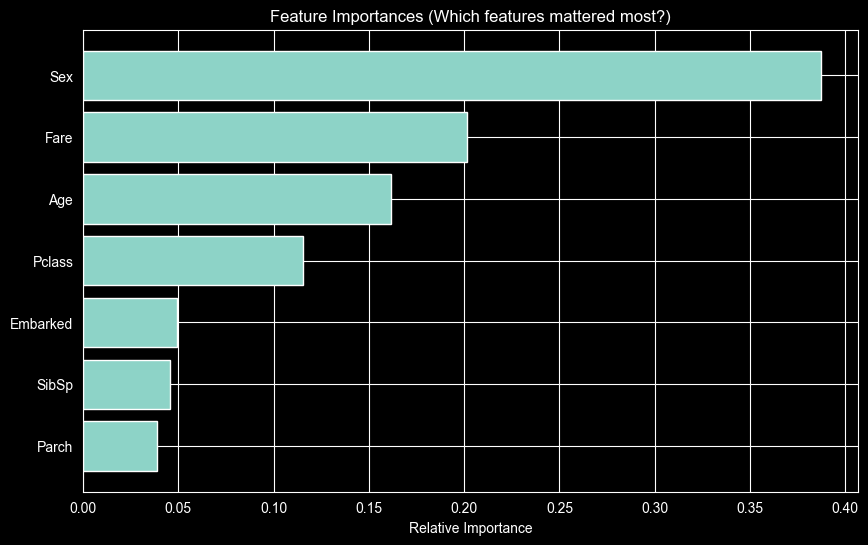

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importance ලබාගනිමු
importances = best_rf_model.feature_importances_
feat_names = features.columns

# ලස්සනට පෙන්වන්න sort කරමු
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Feature Importances (Which features mattered most?)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# අවසාන පරීක්ෂණය (Ultimate Test)

In [41]:
y_final_pred = best_rf_model.predict(X_test)

final_accuracy = round(accuracy_score(y_test, y_final_pred), 3)
final_precision = round(precision_score(y_test, y_final_pred), 3)
recall_final = round(recall_score(y_test, y_final_pred), 3)

print(f'FINAL PERFORMANCE ON TEST SET -- Accuracy: {final_accuracy} / Precision: {final_precision} / Recall: {recall_final}')

FINAL PERFORMANCE ON TEST SET -- Accuracy: 0.827 / Precision: 0.857 / Recall: 0.711
